In [ ]:
import sinter
import stim
from typing import List
from mwpf import SinterMWPFDecoder

noise = [0.01, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
code_distance = [3, 5, 7, 9]

task_configs = [dict(
    circuit=stim.Circuit.generated(
            "repetition_code:memory",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=p,
        ),
        json_metadata={'d': d, 'p': p},
    )
    for d in code_distance
    for p in noise
]
for task in task_configs:
    print(f"**** BEGIN repetition_code:memory {task['json_metadata']}")
    print(task["circuit"])
    print(f"**** END repetition_code:memory {task['json_metadata']}")

**** BEGIN repetition_code:memory {'d': 3, 'p': 0.01}
R 0 1 2 3 4
TICK
DEPOLARIZE1(0.01) 0 2 4
CX 0 1 2 3
TICK
CX 2 1 4 3
TICK
MR 1 3
DETECTOR(1, 0) rec[-2]
DETECTOR(3, 0) rec[-1]
REPEAT 8 {
    TICK
    DEPOLARIZE1(0.01) 0 2 4
    CX 0 1 2 3
    TICK
    CX 2 1 4 3
    TICK
    MR 1 3
    SHIFT_COORDS(0, 1)
    DETECTOR(1, 0) rec[-2] rec[-4]
    DETECTOR(3, 0) rec[-1] rec[-3]
}
M 0 2 4
DETECTOR(1, 1) rec[-2] rec[-3] rec[-5]
DETECTOR(3, 1) rec[-1] rec[-2] rec[-4]
OBSERVABLE_INCLUDE(0) rec[-1]
**** END repetition_code:memory {'d': 3, 'p': 0.01}
**** BEGIN repetition_code:memory {'d': 3, 'p': 0.05}
R 0 1 2 3 4
TICK
DEPOLARIZE1(0.05) 0 2 4
CX 0 1 2 3
TICK
CX 2 1 4 3
TICK
MR 1 3
DETECTOR(1, 0) rec[-2]
DETECTOR(3, 0) rec[-1]
REPEAT 8 {
    TICK
    DEPOLARIZE1(0.05) 0 2 4
    CX 0 1 2 3
    TICK
    CX 2 1 4 3
    TICK
    MR 1 3
    SHIFT_COORDS(0, 1)
    DETECTOR(1, 0) rec[-2] rec[-4]
    DETECTOR(3, 0) rec[-1] rec[-3]
}
M 0 2 4
DETECTOR(1, 1) rec[-2] rec[-3] rec[-5]
DETECTOR(3, 1) rec[-1

In [ ]:

tasks = [
    sinter.Task(**task)
    for task in task_configs
]


mwpf_collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders = ["mwpf"],
    custom_decoders = { "mwpf": SinterMWPFDecoder(cluster_node_limit=50) },
    max_shots=100_000,
    max_errors=500,
)

pymatching_collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders = ["pymatching"],
    max_shots=100_000,
    max_errors=500,
)

In [ ]:
fore_round_data_depolarization=p,
        ),
        json_metadata={'d': d, 'p': p},
    )
    for d in code_distance
    for p in noise
]
for task in task_configs:
    print(task + "\n")

tasks = [
    sinter.Task(**task)
    for task in task_configs
]


mwpf_collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders = ["mwpf"],
    custom_decoders = { "mwpf": SinterMWPFDecoder(cluster_node_limit=50) },
    max_shots=100_000,
    max_errors=500,
)

pymatching_collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders = ["pymatching"],
    max_shots=100_000,
    max_errors=500,
)

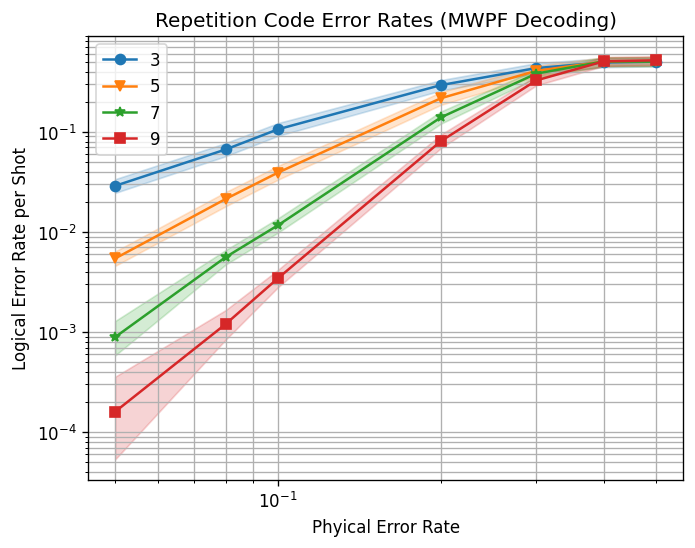

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=mwpf_collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)
ax.set_ylim(1e-4, 1e-0)
ax.set_xlim(5e-2, 5e-1)
ax.loglog()
ax.set_title("Repetition Code Error Rates (MWPF Decoding)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120) 

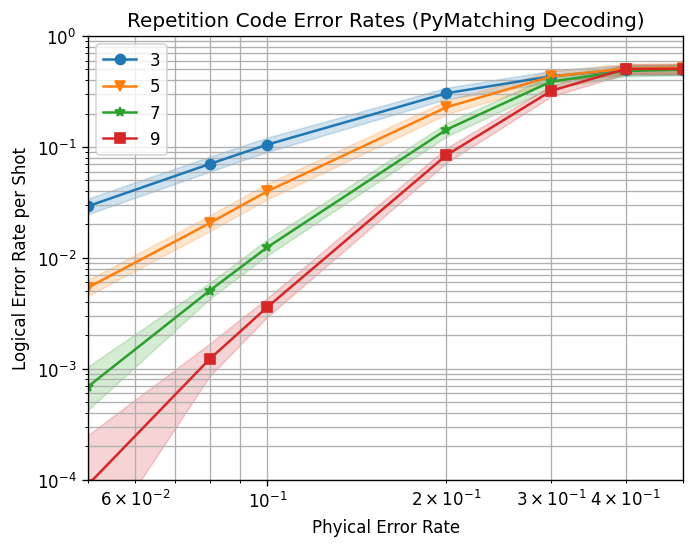

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)
ax.set_ylim(1e-4, 1e-0)
ax.set_xlim(5e-2, 5e-1)
ax.loglog()
ax.set_title("Repetition Code Error Rates (PyMatching Decoding)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120) 

In [ ]:
# From the docs:
# MWPF decoder now supports heralded error decoding in stim circuit!
#   Since the sinter.Decoder interface only gives a DEM (Detector Error Model), which doesn't include heralded error
#   information, you need to manually provide the circuit when constructing the decoder, like below
custom_decoders = { "mwpf": SinterMWPFDecoder(cluster_node_limit=50).with_circuit(circuit) }